In [69]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn

In [70]:
x=torch.arange(0,1,0.001)

In [71]:
y=0.6*x+3

In [72]:
limit=int(0.8*len(x))

In [73]:
x_train=x[:limit]
y_train=y[:limit]
x_test=x[limit:]
y_test=y[limit:]

In [74]:
class regression(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers=nn.Sequential(
                                    nn.Linear(in_features=1,out_features=10),
                                    nn.Linear(in_features=10,out_features=10),
                                    nn.Linear(in_features=10,out_features=10),
                                    nn.Linear(in_features=10,out_features=10),
                                    nn.Linear(in_features=10,out_features=1))
    def forward(self,x):
        return self.layers(x)
        

In [75]:
model=regression().to('mps')
x_train.dtype

torch.float32

In [76]:
epochs=1000
x_train=x_train.to('mps')
y_train=y_train.to('mps')
x_test=x_test.to('mps')
y_test=y_test.to('mps')
loss_fn=nn.L1Loss()
l=[]
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.01)
for epoch in range(epochs):
    model.train()
    y_pred=model(x_train.unsqueeze(dim=1))
    loss=loss_fn(y_pred,y_train.unsqueeze(dim=1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(loss)
    l.append(loss.to('cpu').detach().numpy())
    

tensor(3.0973, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.0711, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.0451, device='mps:0', grad_fn=<MeanBackward0>)
tensor(3.0195, device='mps:0', grad_fn=<MeanBackward0>)
tensor(2.9941, device='mps:0', grad_fn=<MeanBackward0>)
tensor(2.9689, device='mps:0', grad_fn=<MeanBackward0>)
tensor(2.9439, device='mps:0', grad_fn=<MeanBackward0>)
tensor(2.9191, device='mps:0', grad_fn=<MeanBackward0>)
tensor(2.8943, device='mps:0', grad_fn=<MeanBackward0>)
tensor(2.8696, device='mps:0', grad_fn=<MeanBackward0>)
tensor(2.8450, device='mps:0', grad_fn=<MeanBackward0>)
tensor(2.8203, device='mps:0', grad_fn=<MeanBackward0>)
tensor(2.7957, device='mps:0', grad_fn=<MeanBackward0>)
tensor(2.7710, device='mps:0', grad_fn=<MeanBackward0>)
tensor(2.7461, device='mps:0', grad_fn=<MeanBackward0>)
tensor(2.7212, device='mps:0', grad_fn=<MeanBackward0>)
tensor(2.6961, device='mps:0', grad_fn=<MeanBackward0>)
tensor(2.6707, device='mps:0', grad_fn=<MeanBack

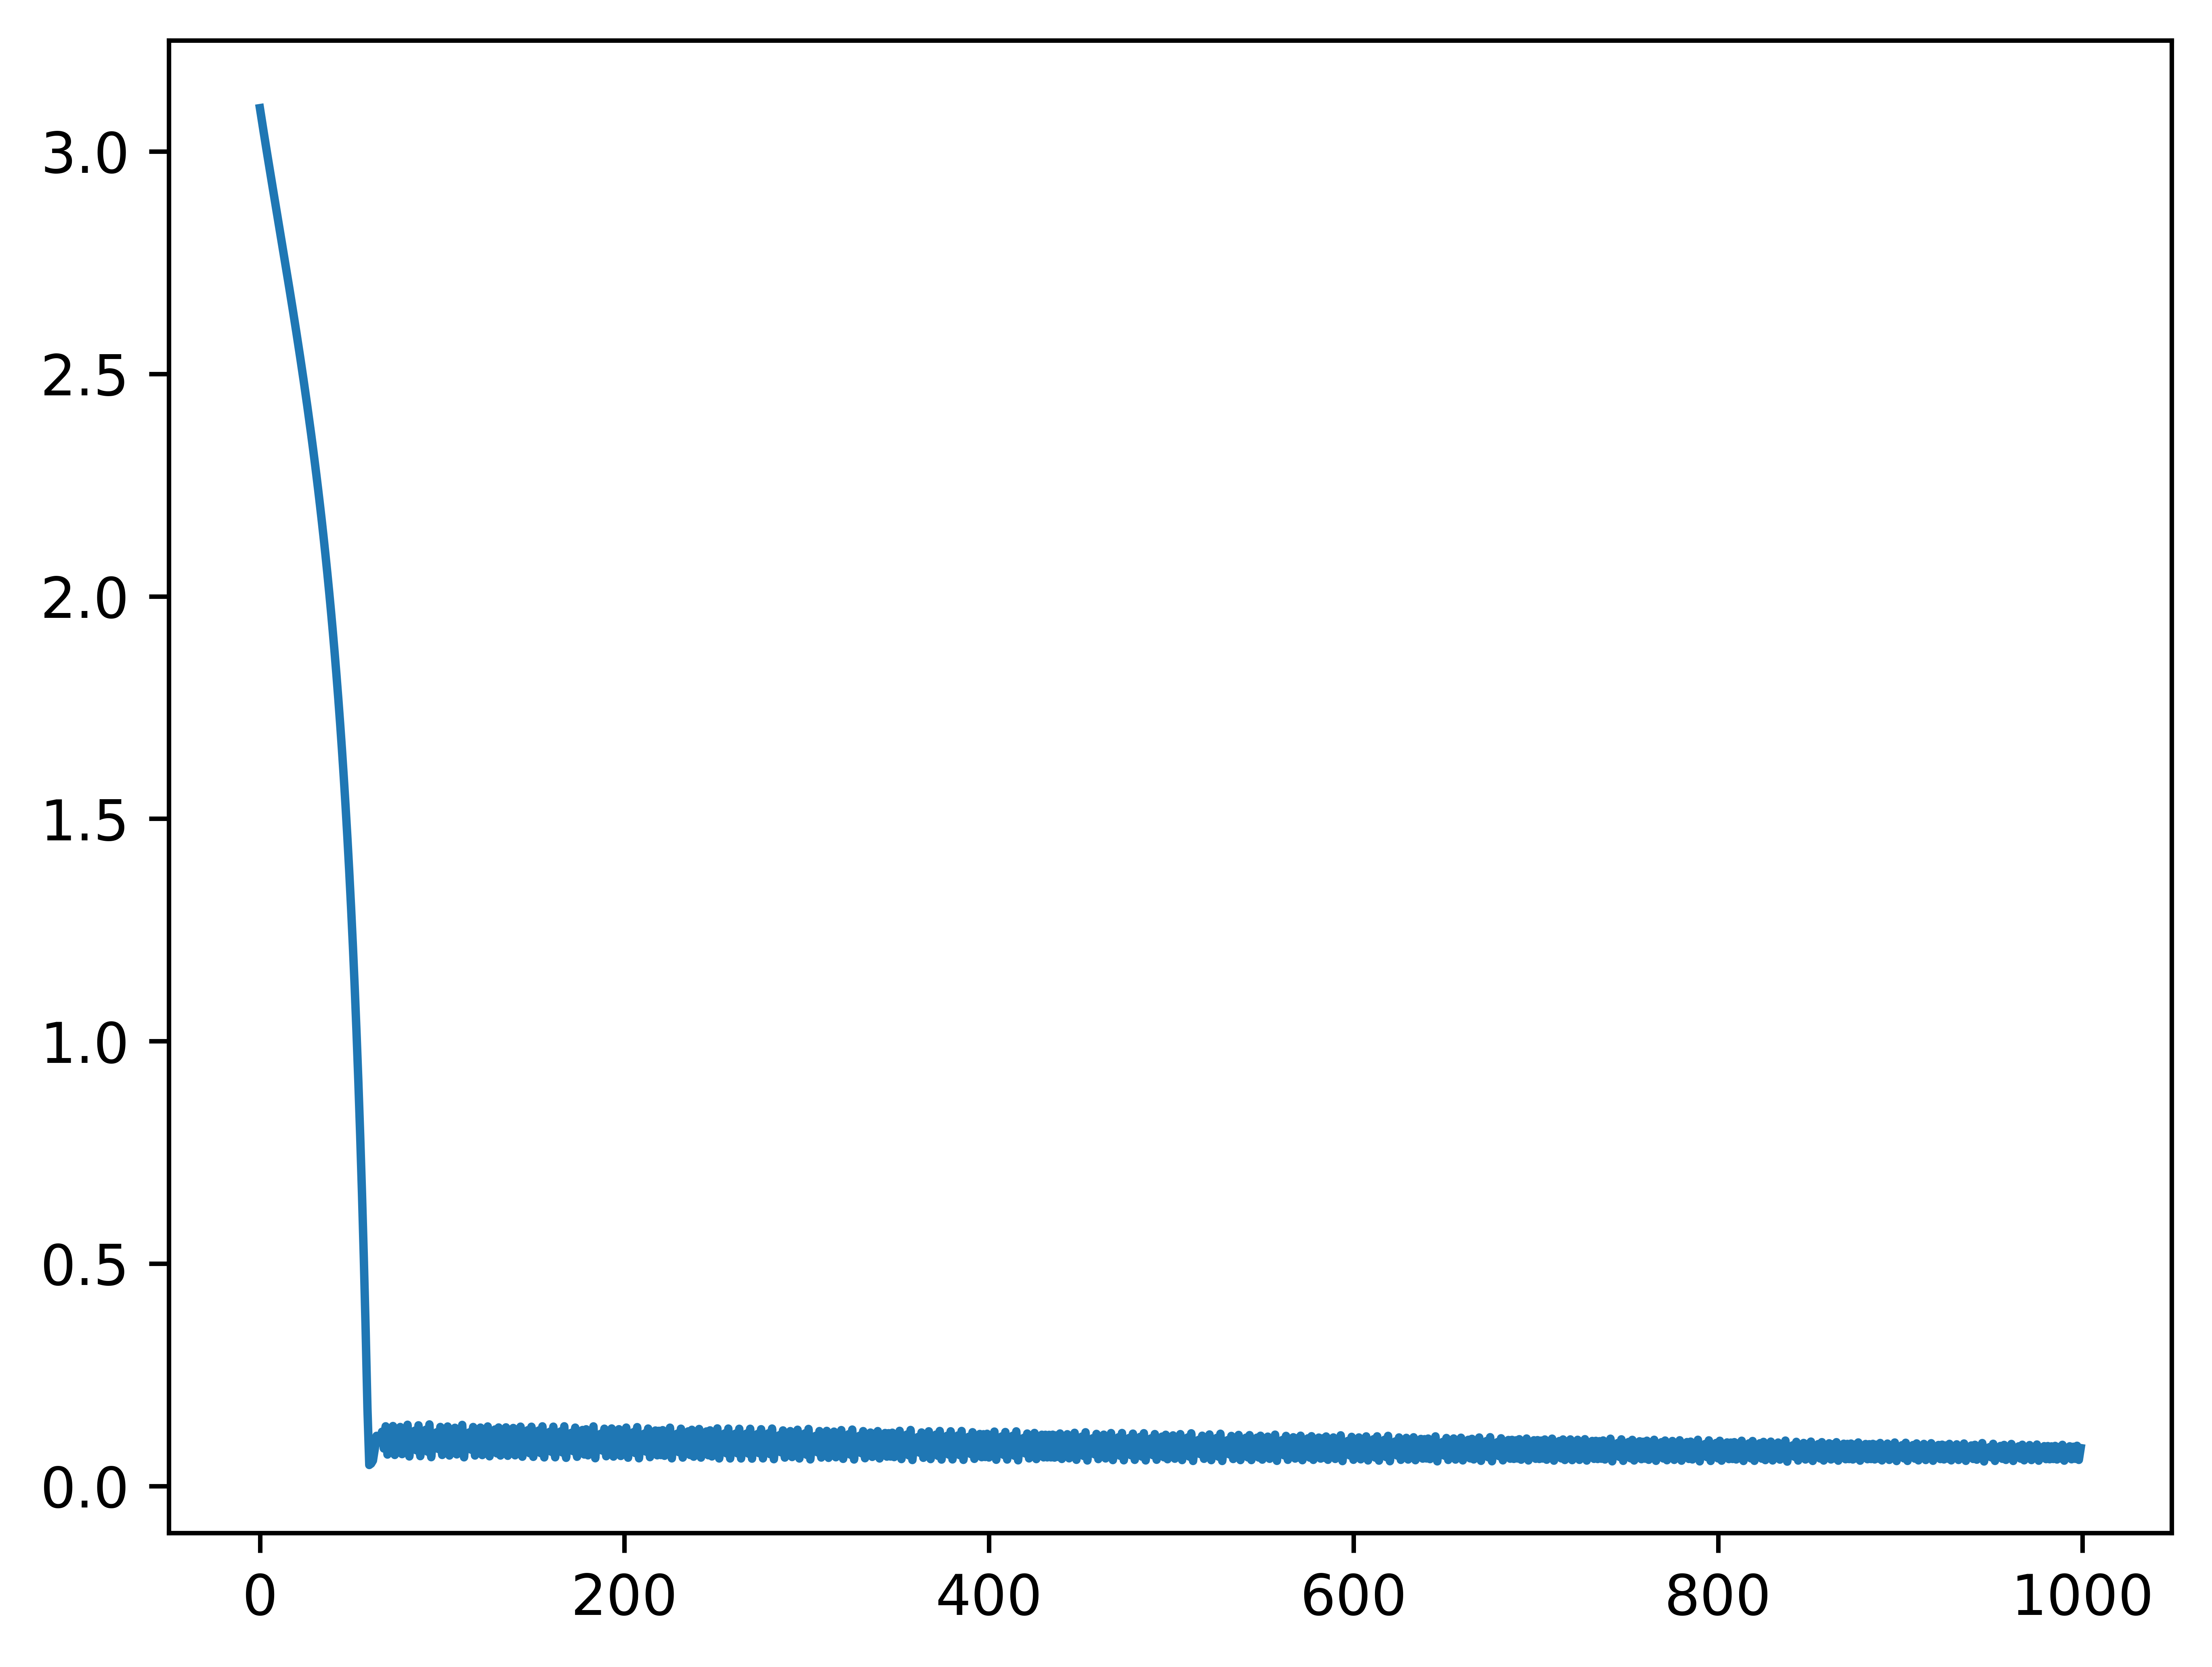

In [77]:
plt.figure(dpi=1000)
plt.plot(l)

In [78]:
from sklearn.datasets import make_circles

In [79]:
x,y=make_circles(1000,random_state=42,noise=0.03)

In [80]:
x

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [81]:
y

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,

In [82]:
from sklearn.model_selection import train_test_split

In [83]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [84]:
y_train.shape,x_train.shape,y_test.shape

((800,), (800, 2), (200,))

In [85]:
x_train=torch.from_numpy(x_train).type(torch.float32).to('mps')
y_train=torch.from_numpy(y_train).type(torch.float32).to('mps')
x_test=torch.from_numpy(x_test).type(torch.float32).to('mps')
y_test=torch.from_numpy(y_test).type(torch.float32).to('mps')

In [86]:
x_train,x_train.dtype

(tensor([[ 0.2145, -0.8042],
         [-0.8102,  0.1609],
         [ 0.7313,  0.3701],
         ...,
         [-0.6332,  0.8260],
         [-0.2399,  0.8069],
         [-0.0213, -0.9963]], device='mps:0'),
 torch.float32)

In [93]:
model_1=nn.Sequential(
    nn.Linear(2,96),
    nn.ReLU(),
    nn.Linear(96,96),
    nn.ReLU(),
    nn.Linear(96,1)
).to('mps')

In [94]:
model_1.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.4748,  0.3244],
                      [-0.1098,  0.0826],
                      [-0.4817,  0.1324],
                      [-0.0311, -0.4717],
                      [-0.0940,  0.3815],
                      [-0.3113,  0.5038],
                      [-0.6719, -0.1753],
                      [ 0.4495,  0.4822],
                      [-0.5476,  0.5368],
                      [ 0.3482,  0.5304],
                      [ 0.4081,  0.1152],
                      [ 0.2656,  0.6342],
                      [-0.5542, -0.0875],
                      [ 0.0654,  0.0509],
                      [ 0.1294, -0.3706],
                      [-0.0423,  0.0347],
                      [-0.3705, -0.1709],
                      [ 0.3351, -0.0198],
                      [-0.3221, -0.0788],
                      [-0.7050,  0.1568],
                      [-0.6737, -0.5965],
                      [-0.6434,  0.0963],
                      [ 0.0596, -0.5603],
        

In [95]:
loss_2=nn.BCEWithLogitsLoss()
optimizer_1=torch.optim.SGD(model_1.parameters(),lr=0.01)

In [96]:
epochs=1000
for epoch in range(epochs):
    model_1.train()
    y_logit=model_1(x_train)
    loss=loss_2(y_logit,y_train.unsqueeze(1))
    y_pred=torch.round(torch.sigmoid(y_logit))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(loss)

tensor(0.6986, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6986, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6986, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6986, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6986, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6986, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6986, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6986, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6986, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6986, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6986, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6986, device='mps:0', grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)
tensor(0.6986, device='mps:0', grad_fn=<